# 📊 Phase 7-1: LLM 벤치마크와 자동 평가
> "벤치마크 점수는 모델의 '이력서'일 뿐이다. 실제 업무 능력은 직접 만든 평가셋에서 드러난다."

## 학습 목표
1. 주요 LLM 벤치마크의 목적과 한계를 이해한다
2. lm-evaluation-harness로 모델을 정량 평가한다
3. DeepEval로 생성 품질을 자동 측정한다
4. SFT 모델 vs 원본 모델의 차이를 정량 비교한다

In [ ]:
# 평가 라이브러리 설치
# !pip install lm-eval deepeval rouge-score bert-score nltk datasets transformers torch -q

In [2]:
import torch
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# GPU 확인
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print(f"✅ GPU: {gpu.name} ({gpu.total_memory // 1024**3}GB)")
    print(f"   VRAM 여유: {torch.cuda.mem_get_info()[0] // 1024**3}GB")
else:
    print("⚠️ CPU 모드 - 평가 시간이 오래 걸립니다")

print(f"\n📅 실행 시각: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

✅ GPU: NVIDIA GeForce RTX 4070 Ti (11GB)
   VRAM 여유: 10GB

📅 실행 시각: 2026-03-16 14:17


---
## 1. 왜 평가가 필요한가: Loss ≠ 품질

| 현상 | Training Loss | 실제 품질 |
|------|:---:|:---:|
| 과적합 | ↓ 매우 낮음 | ❌ 암기만 함 |
| 적절 학습 | ↓ 낮음 | ✅ 일반화 |
| 학습 부족 | → 높음 | ❌ 학습 안 됨 |

**핵심**: Loss가 낮아졌다고 모델이 좋아진 것이 아니다. 평가 없는 파인튜닝은 눈 감고 운전하는 것과 같다.

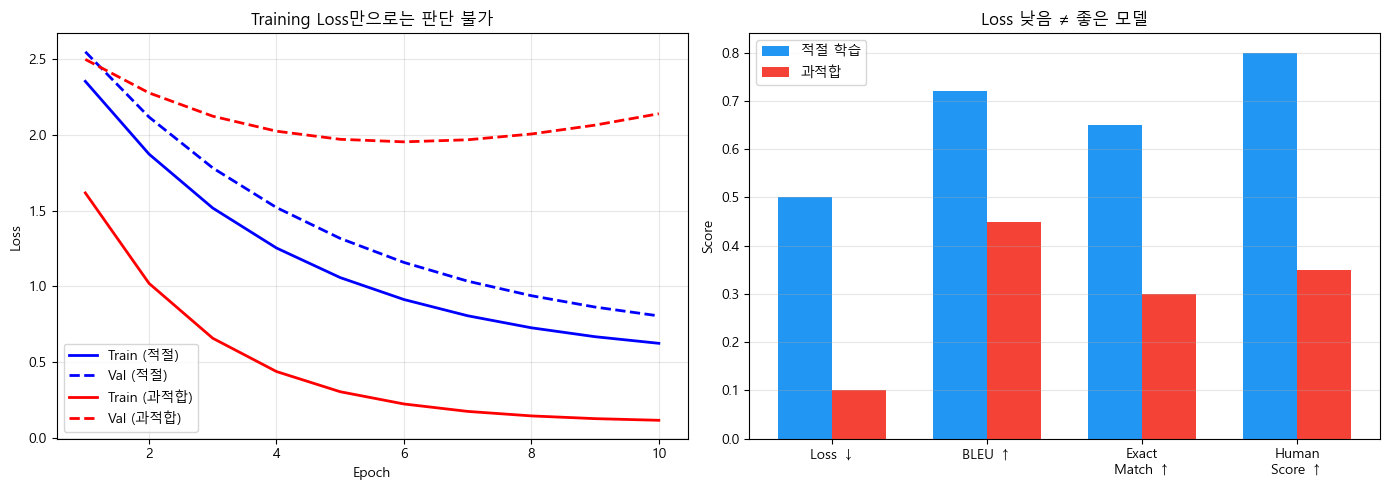

💡 과적합 모델은 Loss가 더 낮지만, 모든 실제 메트릭에서 떨어진다


In [3]:
# Loss ≠ 품질 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Loss curves
epochs = np.arange(1, 11)
loss_good = 2.5 * np.exp(-0.3 * epochs) + 0.5
loss_overfit = 2.5 * np.exp(-0.5 * epochs) + 0.1
val_good = 2.5 * np.exp(-0.25 * epochs) + 0.6
val_overfit = 2.5 * np.exp(-0.2 * epochs) + 0.3 + 0.15 * epochs

axes[0].plot(epochs, loss_good, 'b-', linewidth=2, label='Train (적절)')
axes[0].plot(epochs, val_good, 'b--', linewidth=2, label='Val (적절)')
axes[0].plot(epochs, loss_overfit, 'r-', linewidth=2, label='Train (과적합)')
axes[0].plot(epochs, val_overfit, 'r--', linewidth=2, label='Val (과적합)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss만으로는 판단 불가')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: Metric comparison
categories = ['Loss \u2193', 'BLEU \u2191', 'Exact\nMatch \u2191', 'Human\nScore \u2191']
model_good = [0.5, 0.72, 0.65, 0.80]
model_overfit = [0.1, 0.45, 0.30, 0.35]

x = np.arange(len(categories))
width = 0.35
bars1 = axes[1].bar(x - width/2, model_good, width, label='적절 학습', color='#2196F3')
bars2 = axes[1].bar(x + width/2, model_overfit, width, label='과적합', color='#F44336')
axes[1].set_ylabel('Score')
axes[1].set_title('Loss 낮음 ≠ 좋은 모델')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("💡 과적합 모델은 Loss가 더 낮지만, 모든 실제 메트릭에서 떨어진다")

---
## 2. 주요 LLM 벤치마크 지도

| 벤치마크 | 측정 능력 | 형식 | 규모 | 대표 용도 |
|----------|---------|------|------|----------|
| **MMLU** | 지식 (57개 분야) | 4지선다 | 14K | 일반 지식 평가 |
| **HumanEval** | 코딩 | 함수 완성 | 164 | 코드 생성 능력 |
| **GSM8K** | 수학 추론 | 풀이+정답 | 8.5K | 수학적 사고 |
| **MT-Bench** | 대화 품질 | 멀티턴 | 80 | GPT-4가 채점 |
| **TruthfulQA** | 사실성 | 선택형 | 817 | 환각 방지 |
| **ARC** | 과학 추론 | 4지선다 | 7.8K | 초중등 과학 |
| **HellaSwag** | 상식 추론 | 문장 완성 | 10K | 상식 이해 |
| **Winogrande** | 대명사 해소 | 이항 선택 | 1.7K | 언어 이해 |

### Open LLM Leaderboard 구성
HuggingFace Open LLM Leaderboard는 위 벤치마크의 조합으로 모델을 순위 매김
- **v1**: ARC + HellaSwag + MMLU + TruthfulQA + Winogrande + GSM8K
- **v2**: MMLU-PRO + GPQA + MuSR + MATH-hard + IFEval + BBH (더 어려운 기준)

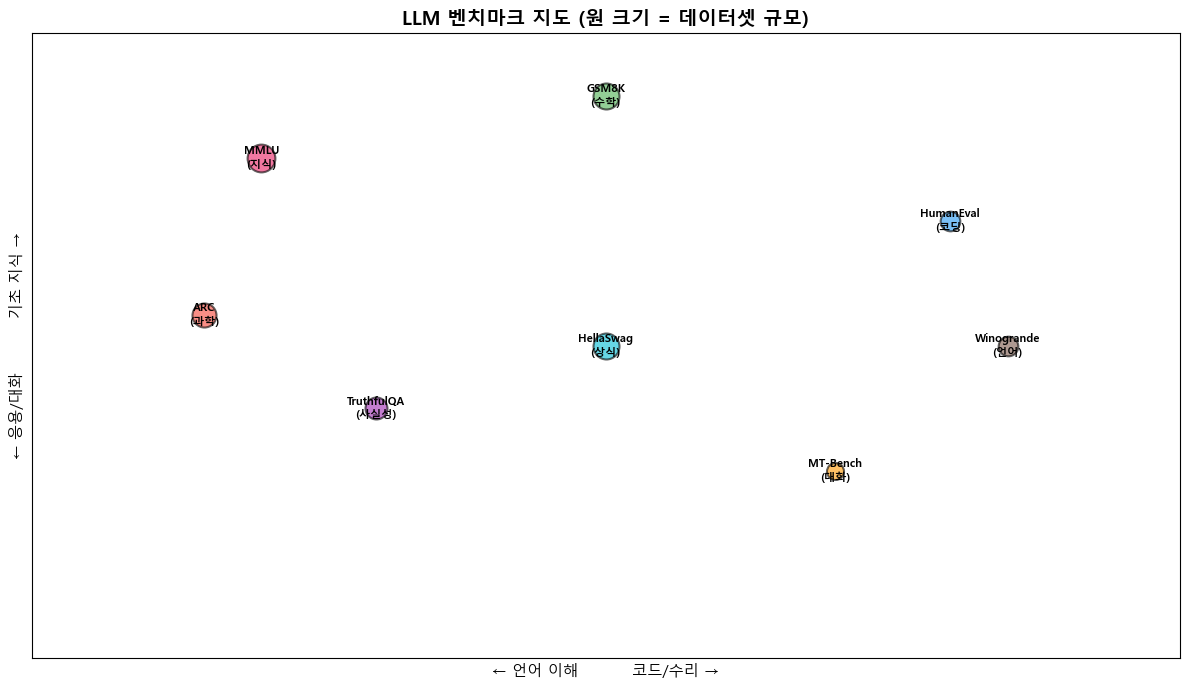

💡 단일 벤치마크로는 모델의 전체 능력을 판단할 수 없다


In [4]:
# 벤치마크 지도 시각화
fig, ax = plt.subplots(figsize=(12, 7))

benchmarks = {
    'MMLU': {'x': 0.2, 'y': 0.8, 'size': 400, 'color': '#E91E63', 'type': '지식'},
    'HumanEval': {'x': 0.8, 'y': 0.7, 'size': 200, 'color': '#2196F3', 'type': '코딩'},
    'GSM8K': {'x': 0.5, 'y': 0.9, 'size': 350, 'color': '#4CAF50', 'type': '수학'},
    'MT-Bench': {'x': 0.7, 'y': 0.3, 'size': 150, 'color': '#FF9800', 'type': '대화'},
    'TruthfulQA': {'x': 0.3, 'y': 0.4, 'size': 250, 'color': '#9C27B0', 'type': '사실성'},
    'ARC': {'x': 0.15, 'y': 0.55, 'size': 300, 'color': '#F44336', 'type': '과학'},
    'HellaSwag': {'x': 0.5, 'y': 0.5, 'size': 350, 'color': '#00BCD4', 'type': '상식'},
    'Winogrande': {'x': 0.85, 'y': 0.5, 'size': 200, 'color': '#795548', 'type': '언어'},
}

for name, info in benchmarks.items():
    ax.scatter(info['x'], info['y'], s=info['size'], c=info['color'], 
               alpha=0.6, edgecolors='black', linewidth=1.5, zorder=5)
    ax.annotate(f"{name}\n({info['type']})", (info['x'], info['y']),
                ha='center', va='center', fontsize=8, fontweight='bold', zorder=10)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('\u2190 언어 이해          코드/수리 \u2192', fontsize=11)
ax.set_ylabel('\u2190 응용/대화          기초 지식 \u2192', fontsize=11)
ax.set_title('LLM 벤치마크 지도 (원 크기 = 데이터셋 규모)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.2)
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()
print("💡 단일 벤치마크로는 모델의 전체 능력을 판단할 수 없다")

---
## 3. lm-evaluation-harness 실전

[EleutherAI/lm-evaluation-harness](https://github.com/EleutherAI/lm-evaluation-harness)는 LLM 평가의 사실상 표준 도구다.

### 설치
```bash
pip install lm-eval
```

### 핵심 매개변수
| 매개변수 | 설명 | 예시 |
|---------|------|------|
| `--model` | 모델 백엔드 | `hf` (HuggingFace) |
| `--model_args` | 모델 경로 + 설정 | `pretrained=Qwen/Qwen2.5-1.5B-Instruct` |
| `--tasks` | 평가 태스크 | `mmlu,gsm8k,arc_easy` |
| `--limit` | 샘플 수 제한 | `50` (빠른 테스트용) |
| `--batch_size` | 배치 크기 | `auto` 또는 `4` |
| `--output_path` | 결과 저장 경로 | `./eval_results/` |

### ⚠️ 주의: --limit 없이 실행하면 시간이 매우 오래 걸립니다!

In [7]:
# ============================================================
# lm-evaluation-harness 실행 (터미널에서 실행)
# ============================================================
# ⚠️ 노트북이 아닌 터미널에서 실행을 권장합니다
# ⚠️ --limit 50으로 제한하여 빠르게 테스트합니다

# --- 방법 1: CLI 명령어 ---
"""
# MMLU (지식 평가) - 약 5-10분
lm_eval --model hf \\
    --model_args pretrained=Qwen/Qwen2.5-1.5B-Instruct,dtype=float16 \\
    --tasks mmlu \\
    --limit 50 \\
    --batch_size 4 \\
    --output_path ./eval_results/qwen_base/

# GSM8K (수학 추론) - 약 10-15분  
lm_eval --model hf \\
    --model_args pretrained=Qwen/Qwen2.5-1.5B-Instruct,dtype=float16 \\
    --tasks gsm8k \\
    --limit 50 \\
    --batch_size 4 \\
    --output_path ./eval_results/qwen_base/

# ARC Easy (과학 추론) - 약 3-5분
lm_eval --model hf \\
    --model_args pretrained=Qwen/Qwen2.5-1.5B-Instruct,dtype=float16 \\
    --tasks arc_easy \\
    --limit 50 \\
    --batch_size 4 \\
    --output_path ./eval_results/qwen_base/
"""

# --- 방법 2: Python API ---
print("=" * 60)
print("lm-evaluation-harness Python API 사용법")
print("=" * 60)

lm_eval_code = """
import lm_eval

results = lm_eval.simple_evaluate(
    model="hf",
    model_args="pretrained=Qwen/Qwen2.5-1.5B-Instruct,dtype=float16",
    tasks=["mmlu", "gsm8k", "arc_easy"],
    limit=50,          # 빠른 테스트용 (전체 평가 시 제거)
    batch_size=4,
    log_samples=True,
)

# 결과 출력
for task, metrics in results['results'].items():
    print(f"[결과] {task}:")
    for metric, value in metrics.items():
        if isinstance(value, (int, float)):
            print(f"   {metric}: {value:.4f}")
"""
print(lm_eval_code)
print("\n 처음에는 반드시 --limit 50으로 테스트하고, 정식 평가 시에만 제거하세요")

lm-evaluation-harness Python API 사용법

import lm_eval

results = lm_eval.simple_evaluate(
    model="hf",
    model_args="pretrained=Qwen/Qwen2.5-1.5B-Instruct,dtype=float16",
    tasks=["mmlu", "gsm8k", "arc_easy"],
    limit=50,          # 빠른 테스트용 (전체 평가 시 제거)
    batch_size=4,
    log_samples=True,
)

# 결과 출력
for task, metrics in results['results'].items():
    print(f"[결과] {task}:")
    for metric, value in metrics.items():
        if isinstance(value, (int, float)):
            print(f"   {metric}: {value:.4f}")


 처음에는 반드시 --limit 50으로 테스트하고, 정식 평가 시에만 제거하세요


---
## 4. 평가 결과 분석: SFT 전후 비교

Phase 4에서 Text-to-SQL로 파인튜닝한 모델과 원본 모델의 벤치마크 점수를 비교합니다.

**예상되는 패턴**:
- SQL 관련 태스크: SFT 모델 ↑↑
- 일반 지식 (MMLU): SFT 모델 ↓ (Catastrophic Forgetting)
- 수학 (GSM8K): 큰 변화 없거나 약간 ↓

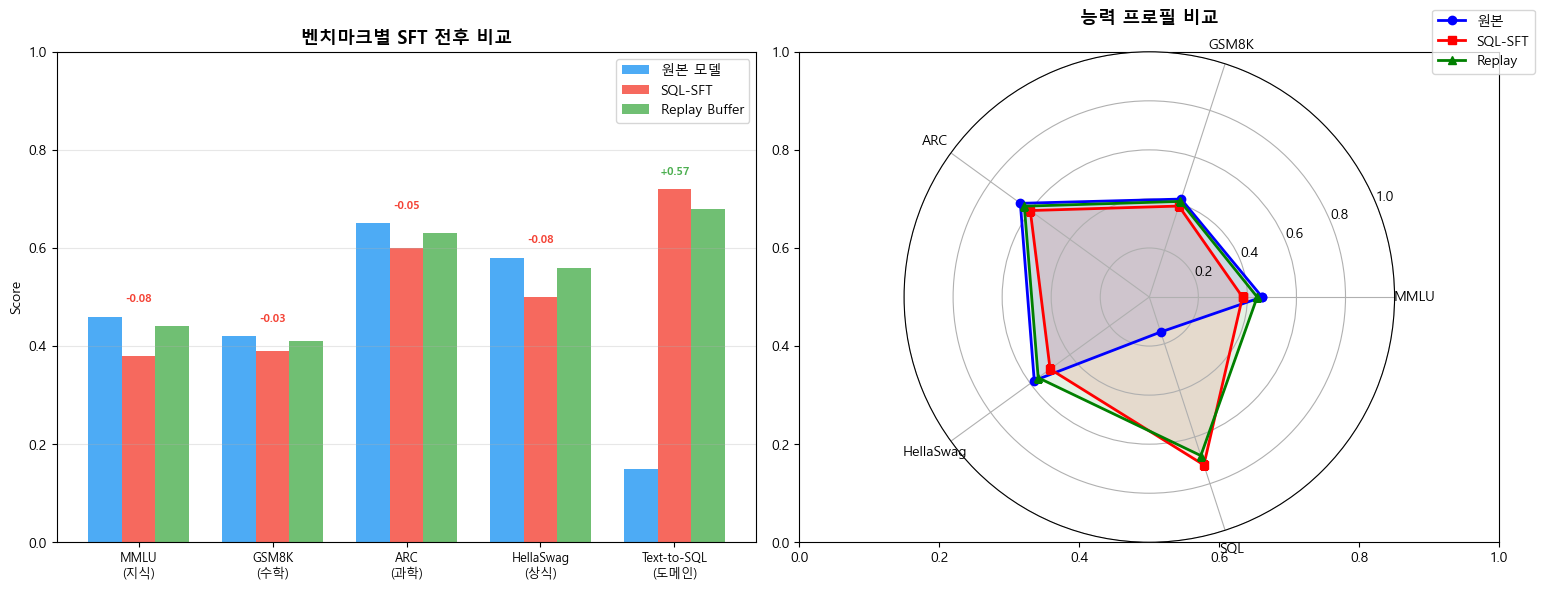

📊 분석 결과:
  • SQL-SFT: SQL 능력 +0.57 향상, 그러나 일반 지식 -0.08 하락 (Forgetting)
  • Replay Buffer: SQL +0.53 (약간 양보), 일반 지식 -0.02 (Forgetting 최소화)
  • 결론: Replay Buffer가 trade-off 측면에서 우수


In [8]:
# SFT 전후 벤치마크 비교 (시뮬레이션)
# 실제로는 lm-eval 결과를 파싱하여 사용

benchmarks = ['MMLU\n(지식)', 'GSM8K\n(수학)', 'ARC\n(과학)', 'HellaSwag\n(상식)', 'Text-to-SQL\n(도메인)']
base_scores = [0.46, 0.42, 0.65, 0.58, 0.15]   # Qwen 1.5B base
sft_scores = [0.38, 0.39, 0.60, 0.50, 0.72]    # SQL-SFT (forgetting 발생)
replay_scores = [0.44, 0.41, 0.63, 0.56, 0.68]  # Replay Buffer (forgetting 완화)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Bar chart comparison
x = np.arange(len(benchmarks))
width = 0.25

bars1 = axes[0].bar(x - width, base_scores, width, label='원본 모델', color='#2196F3', alpha=0.8)
bars2 = axes[0].bar(x, sft_scores, width, label='SQL-SFT', color='#F44336', alpha=0.8)
bars3 = axes[0].bar(x + width, replay_scores, width, label='Replay Buffer', color='#4CAF50', alpha=0.8)

axes[0].set_ylabel('Score')
axes[0].set_title('벤치마크별 SFT 전후 비교', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(benchmarks, fontsize=9)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(0, 1)

# 변화량 표시
for i, (b, s) in enumerate(zip(base_scores, sft_scores)):
    diff = s - b
    color = '#4CAF50' if diff > 0 else '#F44336'
    axes[0].annotate(f'{diff:+.2f}', (i, max(b, s) + 0.03), 
                     ha='center', fontsize=8, color=color, fontweight='bold')

# Panel 2: Radar chart
categories = ['MMLU', 'GSM8K', 'ARC', 'HellaSwag', 'SQL']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

base_vals = base_scores + base_scores[:1]
sft_vals = sft_scores + sft_scores[:1]
replay_vals = replay_scores + replay_scores[:1]

axes[1] = plt.subplot(122, polar=True)
axes[1].plot(angles, base_vals, 'b-o', linewidth=2, label='원본', markersize=6)
axes[1].fill(angles, base_vals, alpha=0.1, color='blue')
axes[1].plot(angles, sft_vals, 'r-s', linewidth=2, label='SQL-SFT', markersize=6)
axes[1].fill(angles, sft_vals, alpha=0.1, color='red')
axes[1].plot(angles, replay_vals, 'g-^', linewidth=2, label='Replay', markersize=6)
axes[1].fill(angles, replay_vals, alpha=0.1, color='green')

axes[1].set_xticks(angles[:-1])
axes[1].set_xticklabels(categories, fontsize=10)
axes[1].set_ylim(0, 1)
axes[1].set_title('능력 프로필 비교', fontsize=13, fontweight='bold', pad=20)
axes[1].legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

print("📊 분석 결과:")
print("  \u2022 SQL-SFT: SQL 능력 +0.57 향상, 그러나 일반 지식 -0.08 하락 (Forgetting)")
print("  \u2022 Replay Buffer: SQL +0.53 (약간 양보), 일반 지식 -0.02 (Forgetting 최소화)")
print("  \u2022 결론: Replay Buffer가 trade-off 측면에서 우수")

---
## 5. DeepEval: 생성 품질 자동 측정

벤치마크는 **선택형/정답형** 태스크에 적합하다. 하지만 실제 생성 태스크(SQL 생성, 대화, 요약)는 **생성된 텍스트의 품질**을 측정해야 한다.

[DeepEval](https://github.com/confident-ai/deepeval)은 LLM 출력의 품질을 다양한 메트릭으로 자동 측정한다.

### 주요 메트릭
| 메트릭 | 측정 대상 | 설명 |
|--------|---------|------|
| **Faithfulness** | 사실 충실도 | 출력이 컨텍스트에 충실한가? |
| **Hallucination** | 환각 | 없는 정보를 만들어 냈는가? |
| **Answer Relevancy** | 관련성 | 질문에 적절히 답했는가? |
| **G-Eval** | 종합 품질 | GPT 기반 종합 평가 |

In [9]:
# ============================================================
# DeepEval 사용법 (개념 + 코드 구조)
# ============================================================

# DeepEval은 내부적으로 OpenAI API 또는 로컬 LLM을 judge로 사용
# 여기서는 코드 구조와 개념을 설명하고, 실행은 선택사항

deepeval_code = """
from deepeval import evaluate
from deepeval.test_case import LLMTestCase
from deepeval.metrics import (
    FaithfulnessMetric,
    HallucinationMetric,
    AnswerRelevancyMetric
)

# 테스트 케이스 정의
test_case = LLMTestCase(
    input="departments 테이블에서 직원 수가 10명 이상인 부서를 조회하는 SQL을 작성해줘",
    actual_output="SELECT department_name FROM departments WHERE employee_count >= 10",
    expected_output="SELECT department_name FROM departments WHERE employee_count >= 10",
    context=["departments 테이블에는 department_name, employee_count 컨럼이 있다"]
)

# 메트릭 정의
faithfulness = FaithfulnessMetric(threshold=0.7)
hallucination = HallucinationMetric(threshold=0.5)
relevancy = AnswerRelevancyMetric(threshold=0.7)

# 평가 실행
results = evaluate([test_case], [faithfulness, hallucination, relevancy])

# 결과 확인
for result in results:
    print(f"Metric: {result.metric_name}")
    print(f"Score: {result.score}")
    print(f"Passed: {result.success}")
"""

print("DeepEval 평가 코드 구조:")
print(deepeval_code)

print("\n" + "=" * 60)
print("⚠️ DeepEval 주의사항:")
print("=" * 60)
print("1. Faithfulness, Hallucination 등은 내부적으로 LLM judge 사용")
print("2. DEEPEVAL_API_KEY 또는 로컬 모델 설정 필요")
print("3. 로컬 모델 judge: 1.5B 모델로는 부정확 \u2192 최소 7B 이상 권장")
print("4. 무료 대안: BLEU, ROUGE, BERTScore (다음 노트북에서 다룸)")

DeepEval 평가 코드 구조:

from deepeval import evaluate
from deepeval.test_case import LLMTestCase
from deepeval.metrics import (
    FaithfulnessMetric,
    HallucinationMetric,
    AnswerRelevancyMetric
)

# 테스트 케이스 정의
test_case = LLMTestCase(
    input="departments 테이블에서 직원 수가 10명 이상인 부서를 조회하는 SQL을 작성해줘",
    actual_output="SELECT department_name FROM departments WHERE employee_count >= 10",
    expected_output="SELECT department_name FROM departments WHERE employee_count >= 10",
    context=["departments 테이블에는 department_name, employee_count 컨럼이 있다"]
)

# 메트릭 정의
faithfulness = FaithfulnessMetric(threshold=0.7)
hallucination = HallucinationMetric(threshold=0.5)
relevancy = AnswerRelevancyMetric(threshold=0.7)

# 평가 실행
results = evaluate([test_case], [faithfulness, hallucination, relevancy])

# 결과 확인
for result in results:
    print(f"Metric: {result.metric_name}")
    print(f"Score: {result.score}")
    print(f"Passed: {result.success}")


⚠️ DeepEval 주의사항:
1. Faithfulness, Hallucination 

---
## 6. 직접 만드는 간이 평가 함수

DeepEval 같은 프레임워크 없이도, 기본적인 평가는 직접 구현할 수 있다.

### 평가 접근법
1. **Exact Match**: 정답과 완전 일치 (가장 엄격)
2. **Keyword Match**: 핵심 키워드 포함 여부 (유연)
3. **구조적 검증**: SQL 문법, JSON 형식 등 (도메인 특화)

In [10]:
# ============================================================
# 직접 만드는 간이 평가 함수
# ============================================================
import re
from typing import Dict, List, Tuple

def evaluate_sql_output(predicted: str, expected: str) -> Dict[str, float]:
    """SQL 생성 품질 평가 (Phase 7-2에서 확장 예정)"""
    results = {}
    
    # 1. Exact Match (정규화 후 비교)
    def normalize_sql(sql: str) -> str:
        sql = sql.upper().strip()
        sql = re.sub(r'\s+', ' ', sql)
        sql = sql.replace(' ;', ';').rstrip(';')
        return sql
    
    pred_norm = normalize_sql(predicted)
    exp_norm = normalize_sql(expected)
    results['exact_match'] = 1.0 if pred_norm == exp_norm else 0.0
    
    # 2. Keyword Match (핵심 SQL 키워드)
    keywords = ['SELECT', 'FROM', 'WHERE', 'JOIN', 'GROUP BY', 'ORDER BY', 
                'HAVING', 'INSERT', 'UPDATE', 'DELETE', 'LIMIT']
    pred_keywords = set(kw for kw in keywords if kw in pred_norm)
    exp_keywords = set(kw for kw in keywords if kw in exp_norm)
    
    if exp_keywords:
        keyword_precision = len(pred_keywords & exp_keywords) / len(pred_keywords) if pred_keywords else 0
        keyword_recall = len(pred_keywords & exp_keywords) / len(exp_keywords)
        results['keyword_f1'] = 2 * keyword_precision * keyword_recall / (keyword_precision + keyword_recall) if (keyword_precision + keyword_recall) > 0 else 0
    else:
        results['keyword_f1'] = 0.0
    
    # 3. 구조적 유사도 (테이블명, 컨럼명 매칭)
    def extract_identifiers(sql: str) -> set:
        tokens = re.findall(r'\b[a-zA-Z_][a-zA-Z0-9_]*\b', sql.lower())
        sql_reserved = {'select', 'from', 'where', 'and', 'or', 'not', 'in', 
                        'join', 'on', 'group', 'by', 'order', 'having', 'as',
                        'asc', 'desc', 'limit', 'offset', 'union', 'all',
                        'insert', 'into', 'values', 'update', 'set', 'delete',
                        'create', 'table', 'drop', 'alter', 'index', 'between',
                        'like', 'is', 'null', 'count', 'sum', 'avg', 'max', 'min',
                        'distinct', 'case', 'when', 'then', 'else', 'end', 'left',
                        'right', 'inner', 'outer', 'cross', 'natural', 'exists',
                        'upper', 'lower'}
        return set(tokens) - sql_reserved
    
    pred_ids = extract_identifiers(predicted)
    exp_ids = extract_identifiers(expected)
    
    if exp_ids:
        id_recall = len(pred_ids & exp_ids) / len(exp_ids)
        results['identifier_recall'] = id_recall
    else:
        results['identifier_recall'] = 1.0
    
    # 종합 점수
    results['composite_score'] = (
        results['exact_match'] * 0.4 +
        results['keyword_f1'] * 0.3 +
        results['identifier_recall'] * 0.3
    )
    
    return results


# 테스트
test_cases = [
    {
        'predicted': "SELECT name FROM employees WHERE department = 'Engineering'",
        'expected': "SELECT name FROM employees WHERE department = 'Engineering'",
        'desc': '완전 일치'
    },
    {
        'predicted': "select name from employees where department = 'Engineering'",
        'expected': "SELECT name FROM employees WHERE department = 'Engineering'",
        'desc': '대소문자만 다름'
    },
    {
        'predicted': "SELECT employee_name FROM emp WHERE dept = 'Eng'",
        'expected': "SELECT name FROM employees WHERE department = 'Engineering'",
        'desc': '구조는 같지만 이름 다름'
    },
    {
        'predicted': "SELECT COUNT(*) FROM employees GROUP BY department",
        'expected': "SELECT name FROM employees WHERE department = 'Engineering'",
        'desc': '완전히 다른 쿼리'
    },
]

print("📊 SQL 평가 함수 테스트 결과")
print("=" * 70)
for tc in test_cases:
    result = evaluate_sql_output(tc['predicted'], tc['expected'])
    print(f"\n🔍 {tc['desc']}")
    print(f"   예측: {tc['predicted']}")
    print(f"   정답: {tc['expected']}")
    print(f"   Exact Match:      {result['exact_match']:.2f}")
    print(f"   Keyword F1:       {result['keyword_f1']:.2f}")
    print(f"   Identifier Recall:{result['identifier_recall']:.2f}")
    print(f"   종합 점수:        {result['composite_score']:.2f}")

📊 SQL 평가 함수 테스트 결과

🔍 완전 일치
   예측: SELECT name FROM employees WHERE department = 'Engineering'
   정답: SELECT name FROM employees WHERE department = 'Engineering'
   Exact Match:      1.00
   Keyword F1:       1.00
   Identifier Recall:1.00
   종합 점수:        1.00

🔍 대소문자만 다름
   예측: select name from employees where department = 'Engineering'
   정답: SELECT name FROM employees WHERE department = 'Engineering'
   Exact Match:      1.00
   Keyword F1:       1.00
   Identifier Recall:1.00
   종합 점수:        1.00

🔍 구조는 같지만 이름 다름
   예측: SELECT employee_name FROM emp WHERE dept = 'Eng'
   정답: SELECT name FROM employees WHERE department = 'Engineering'
   Exact Match:      0.00
   Keyword F1:       1.00
   Identifier Recall:0.00
   종합 점수:        0.30

🔍 완전히 다른 쿼리
   예측: SELECT COUNT(*) FROM employees GROUP BY department
   정답: SELECT name FROM employees WHERE department = 'Engineering'
   Exact Match:      0.00
   Keyword F1:       0.67
   Identifier Recall:0.50
   종합 점수:        0.35


---
## 7. 평가 메트릭 선택 가이드

| 태스크 유형 | 추천 메트릭 | 이유 |
|------------|-----------|------|
| **분류** (감정, 토픽) | Accuracy, F1 | 정답이 명확 |
| **코드/SQL 생성** | Exact Match + 실행 정확도 | 실행 결과가 최종 판단 |
| **번역** | BLEU, COMET | n-gram 겹침 + 의미 유사도 |
| **요약** | ROUGE-L, BERTScore | 핵심 정보 포함 여부 |
| **대화** | MT-Bench, Human Eval | 자동 메트릭 한계 |
| **사실성** | Faithfulness, TruthfulQA | 환각 검출 |

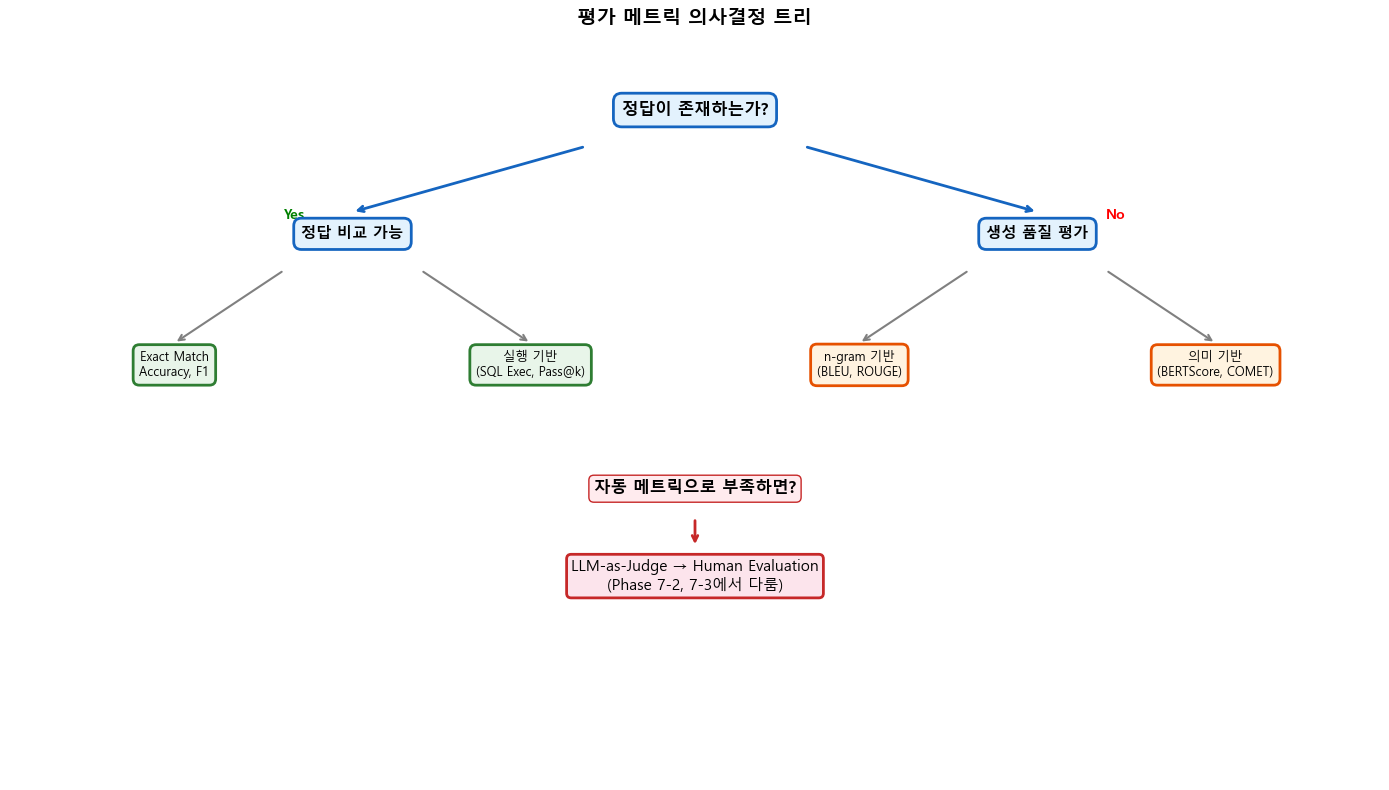

In [12]:
# 평가 전략 의사결정 트리
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# 노드 스타일
box_style = dict(boxstyle='round,pad=0.5', facecolor='#E3F2FD', edgecolor='#1565C0', linewidth=2)
leaf_style_green = dict(boxstyle='round,pad=0.5', facecolor='#E8F5E9', edgecolor='#2E7D32', linewidth=2)
leaf_style_blue = dict(boxstyle='round,pad=0.5', facecolor='#FFF3E0', edgecolor='#E65100', linewidth=2)

# Root
ax.text(5, 9.2, '정답이 존재하는가?', ha='center', va='center', fontsize=12, 
        fontweight='bold', bbox=box_style)

# Level 2
ax.annotate('', xy=(2.5, 7.8), xytext=(4.2, 8.7),
            arrowprops=dict(arrowstyle='->', color='#1565C0', lw=2))
ax.text(2.0, 7.7, 'Yes', fontsize=10, color='green', fontweight='bold')
ax.text(2.5, 7.5, '정답 비교 가능', ha='center', va='center', fontsize=11, 
        fontweight='bold', bbox=box_style)

ax.annotate('', xy=(7.5, 7.8), xytext=(5.8, 8.7),
            arrowprops=dict(arrowstyle='->', color='#1565C0', lw=2))
ax.text(8.0, 7.7, 'No', fontsize=10, color='red', fontweight='bold')
ax.text(7.5, 7.5, '생성 품질 평가', ha='center', va='center', fontsize=11, 
        fontweight='bold', bbox=box_style)

# Level 3 - Left
ax.annotate('', xy=(1.2, 6.0), xytext=(2.0, 7.0),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
ax.text(1.2, 5.7, 'Exact Match\nAccuracy, F1', ha='center', va='center', fontsize=9, 
        bbox=leaf_style_green)

ax.annotate('', xy=(3.8, 6.0), xytext=(3.0, 7.0),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
ax.text(3.8, 5.7, '실행 기반\n(SQL Exec, Pass@k)', ha='center', va='center', fontsize=9, 
        bbox=leaf_style_green)

# Level 3 - Right
ax.annotate('', xy=(6.2, 6.0), xytext=(7.0, 7.0),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
ax.text(6.2, 5.7, 'n-gram 기반\n(BLEU, ROUGE)', ha='center', va='center', fontsize=9, 
        bbox=leaf_style_blue)

ax.annotate('', xy=(8.8, 6.0), xytext=(8.0, 7.0),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
ax.text(8.8, 5.7, '의미 기반\n(BERTScore, COMET)', ha='center', va='center', fontsize=9, 
        bbox=leaf_style_blue)

# Bottom note
ax.text(5, 4.0, '자동 메트릭으로 부족하면?', ha='center', va='center', fontsize=12,
        fontweight='bold', bbox=dict(boxstyle='round', facecolor='#FFEBEE', edgecolor='#C62828'))
ax.annotate('', xy=(5, 3.2), xytext=(5, 3.6),
            arrowprops=dict(arrowstyle='->', color='#C62828', lw=2))
ax.text(5, 2.8, 'LLM-as-Judge \u2192 Human Evaluation\n(Phase 7-2, 7-3에서 다룸)', 
        ha='center', va='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='#FCE4EC', edgecolor='#C62828', linewidth=2))

ax.set_title('평가 메트릭 의사결정 트리', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

---
## 8. 핵심 정리

### 이번 노트북에서 배운 것
1. **Loss ≠ 품질**: Training loss만으로 모델 품질을 판단할 수 없다
2. **벤치마크 지도**: MMLU(지식), GSM8K(수학), HumanEval(코드) 등 목적별 벤치마크
3. **lm-eval**: `--limit`으로 빠르게 테스트, 정식 평가는 전체 데이터셋으로
4. **SFT 전후 비교**: 도메인 능력 ↑ but 일반 능력 ↓ (Forgetting의 정량적 증거)
5. **DeepEval**: Faithfulness, Hallucination 등 생성 품질 메트릭
6. **커스텀 평가 함수**: SQL Exact Match + Keyword F1 + Identifier Recall

### 다음 단계
- **Phase 7-2**: 100개 커스텀 평가셋 구축 + BLEU/ROUGE/BERTScore
- **Phase 7-3**: Human Evaluation과 A/B 테스트

> 💡 **핵심 원칙**: 벤치마크는 '이력서'다. 이력서가 화려해도 면접(커스텀 평가)에서 떨어질 수 있다. 최종 판단은 실무자(사람)의 몲이다.

In [13]:
# Phase 7-1 체크포인트
checkpoint = {
    "phase": "7-1",
    "title": "LLM 벤치마크와 자동 평가",
    "completed": [
        "✅ Loss ≠ 품질 이해 (과적합의 함정)",
        "✅ 8개 주요 벤치마크 특성 파악",
        "✅ lm-evaluation-harness CLI + Python API",
        "✅ SFT 전후 벤치마크 비교 분석",
        "✅ DeepEval 메트릭 개념",
        "✅ SQL 평가 함수 직접 구현",
    ],
    "next": "Phase 7-2: 커스텀 평가셋 구축",
    "key_insight": "벤치마크 점수는 모델의 이력서일 뿐, 실제 업무 능력은 직접 만든 평가셋에서 드러난다"
}

print("🏁 Phase 7-1 체크포인트")
print("=" * 50)
for item in checkpoint["completed"]:
    print(f"  {item}")
print(f"\n🔜 다음: {checkpoint['next']}")
print(f"\n💎 핵심: {checkpoint['key_insight']}")

🏁 Phase 7-1 체크포인트
  ✅ Loss ≠ 품질 이해 (과적합의 함정)
  ✅ 8개 주요 벤치마크 특성 파악
  ✅ lm-evaluation-harness CLI + Python API
  ✅ SFT 전후 벤치마크 비교 분석
  ✅ DeepEval 메트릭 개념
  ✅ SQL 평가 함수 직접 구현

🔜 다음: Phase 7-2: 커스텀 평가셋 구축

💎 핵심: 벤치마크 점수는 모델의 이력서일 뿐, 실제 업무 능력은 직접 만든 평가셋에서 드러난다
